# 网络中的网络（NiN）
---
## 环境配置

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import numpy as np
import pypto
import torch
import torch_npu
import torchvision
from torch import nn
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTODropoutModule import PyPTODropout
from src.D2LFunction import *
from src.AnswerUtlis import *
from src import Models
import torchinfo

---

&emsp;&emsp;NiN 网络构造如下：

In [2]:
class NiN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.net = nn.Sequential(
            self._nin_block(self.in_channels, 96, kernel_size=11, stride=4, padding=0),
            nn.MaxPool2d(kernel_size=3, stride=2),
            self._nin_block(96, 256, kernel_size=5, stride=1, padding=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            self._nin_block(256, 384, kernel_size=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout(p=0.5),
            self._nin_block(384, self.num_classes, kernel_size=3, stride=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten())
    
    def _nin_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU())
    
    def forward(self, x):
        return self.net(x)

In [3]:
class NiN_pypto(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, device='npu:0') -> None:
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.net = nn.Sequential(
            self._nin_block(in_channels, 96, kernel_size=11, stride=4, padding=0, device=device),
            PyPTOMaxPool2d(kernel_size=3, stride=2),
            self._nin_block(96, 256, kernel_size=5, stride=1, padding=2, device=device),
            PyPTOMaxPool2d(kernel_size=3, stride=2),
            self._nin_block(256, 384, kernel_size=3, stride=1, padding=1, device=device),
            PyPTOMaxPool2d(kernel_size=3, stride=2),
            PyPTODropout(p=0.5),
            self._nin_block(384, num_classes, kernel_size=3, stride=1, padding=1, device=device),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()).to(device)
    
    def _nin_block(self, in_channels, out_channels, kernel_size, stride, padding, device='npu:0'):
        return nn.Sequential(
            PyPTOConv2d(in_channels, out_channels, kernel_size, stride, padding, bias=True, device=device),
            nn.ReLU(),
            PyPTOConv2d(out_channels, out_channels, kernel_size=1, bias=True, device=device),
            nn.ReLU(),
            PyPTOConv2d(out_channels, out_channels, kernel_size=1, bias=True, device=device),
            nn.ReLU()).to(device)
    
    def forward(self, x):
        return self.net(x)

---
## 练习 7.3.1

调整NiN的超参数，以提高分类准确性。

### 解答

&emsp;&emsp;首先加载必要的包以及训练函数。模型超参数主要有三个：学习率、训练轮数和批量大小。通过对比不同超参数组合下的训练/测试准确率，找到最优配置。

使用 `torch` 编程进行验证：

**训练:**

In [4]:
import os
pth = '../data/ch07_output/'
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 5 组超参 × NiN(torch 版) 训练 (hyper_params 循环,
#   Nin_hp0-hp4, 每组 30 epochs @96, 约 5×1.5h)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, torch 版训练全部注释;
# 仅保留 pth 与 hyper_params 定义 (供 ccode[5] PyPTO 训练与画图 cell 使用)。
# 如需恢复 torch 训练: 取消下方 for 循环注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
hyper_0 = [0.1, 30, 128]
hyper_1 = [0.08, 30, 128]
hyper_2 = [0.1, 30, 64]
hyper_3 = [0.1, 30, 512]
hyper_4 = [0.2, 30, 128]
hyper_params = [hyper_0, hyper_1, hyper_2, hyper_3, hyper_4]
# idx = 0
# for hyper in hyper_params:
#     lr, num_epochs, batch_size = hyper[0], hyper[1], hyper[2]
#     NiN = Models.NiN()
#     resize = 96
#     train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=resize)
#     train_models(NiN, train_loader, test_loader, num_epochs, lr, net_type=f'Nin_hp{idx}', csv_prefix='ch7_03')
#     idx += 1

**展示:**

In [5]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版 NiN 超参 sweep 曲线 (Nin_hp0-hp4),
#   依赖 ccode[3] 的 torch 训练产出 CSV 列, 该训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[3] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(os.path.join(pth, 'ch7_03.csv'),
#              [('Nin_hp0_epoch_train', 'Nin_hp0_train_loss'),
#               ('Nin_hp1_epoch_train', 'Nin_hp1_train_loss'),
#               ('Nin_hp2_epoch_train', 'Nin_hp2_train_loss'),
#               ('Nin_hp3_epoch_train', 'Nin_hp3_train_loss'),
#               ('Nin_hp4_epoch_train', 'Nin_hp4_train_loss')],
#              title='the loss in train of NiN with different hyperparameters')
# draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
#              [('Nin_hp0_epoch_test', 'Nin_hp0_test_acc'),
#               ('Nin_hp1_epoch_test', 'Nin_hp1_test_acc'),
#               ('Nin_hp2_epoch_test', 'Nin_hp2_test_acc'),
#               ('Nin_hp3_epoch_test', 'Nin_hp3_test_acc'),
#               ('Nin_hp4_epoch_test', 'Nin_hp4_test_acc')],
#              title='the acc in test of NiN with different hyperparameters')

使用 `PyPTO` 编程进行验证：

**训练:**

In [6]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 5 组超参 × NiN_pypto 训练 (hyper_params 循环,
#   hp0-hp4, 每组 30 epochs @96)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则, 仅保留 hp0 完整训练
# (NiN_pypto, lr=0.1, epochs=30, batch_size=128, resize=96)。
# 如需恢复全部训练: 将下方 for 循环改回 'for hyper in hyper_params:', 并删除本注释块。
# 注意: 完整跑全部超参预计 ~4-6h (每次训练含 PyPTO kernel 编译时间)。
# ══════════════════════════════════════════════════════════════════════
idx = 0
for hyper in [hyper_params[0]]:          # 原为 hyper_params (5 组), 验证模式仅 hp0
    lr, num_epochs, batch_size = hyper[0], hyper[1], hyper[2]
    NiN_pypto = Models.NiN_pypto(device=device)
    resize = 96
    train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=resize)
    train_models(NiN_pypto, train_loader, test_loader, num_epochs, lr,
                 net_type=f'Nin_pypto_hp{idx}', csv_prefix='ch7_03', device=device, show_progress=False)  # show_progress=False: 规避 PyPTO 编译期 kernel 死
    idx += 1
# 以下 4 组为验证模式注释掉的训练 (恢复时改回循环即可):
#   hyper_1 = [0.08, 30, 128]  (Nin_pypto_hp1)
#   hyper_2 = [0.1, 30, 64]    (Nin_pypto_hp2)
#   hyper_3 = [0.1, 30, 512]   (Nin_pypto_hp3)
#   hyper_4 = [0.2, 30, 128]   (Nin_pypto_hp4)

**展示:**

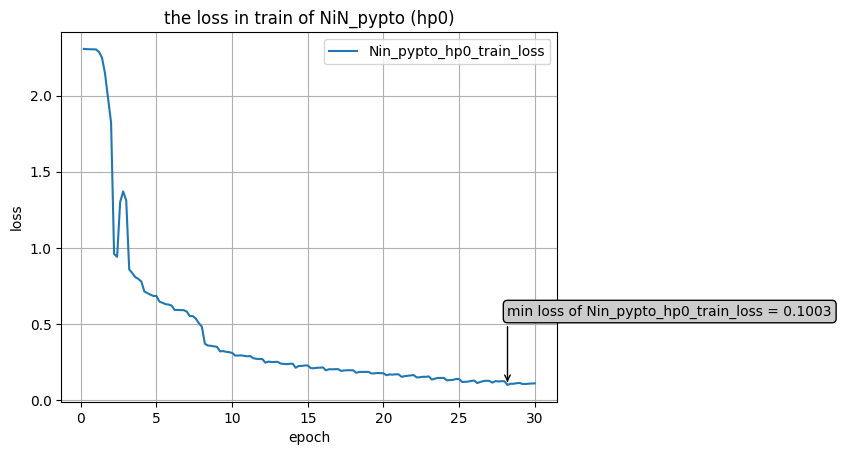

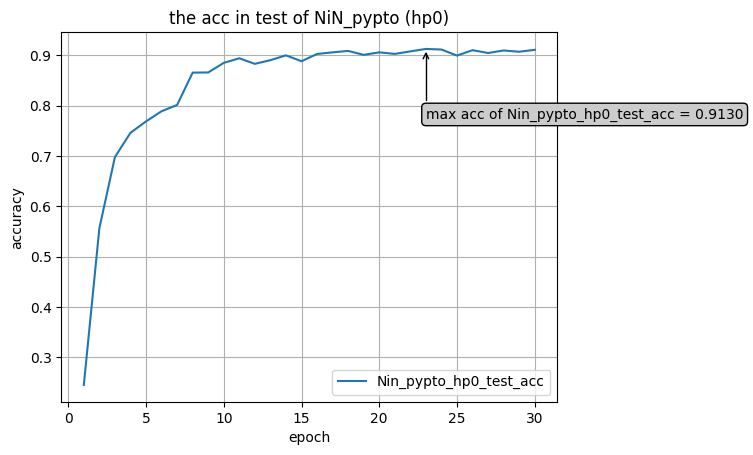

In [7]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 label_list 含 Nin_pypto_hp0-hp4 共 5 组曲线,
#   其余 4 组训练已注释 (ccode[5]), 仅保留 hp0 的 train_loss 与 test_acc 两列。
# 如需恢复全部曲线: 恢复 ccode[5] 全部训练后, 恢复原 label_list。
# ══════════════════════════════════════════════════════════════════════
draw_figures(os.path.join(pth, 'ch7_03.csv'),
             [('Nin_pypto_hp0_epoch_train', 'Nin_pypto_hp0_train_loss')],
             title='the loss in train of NiN_pypto (hp0)')
draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
             [('Nin_pypto_hp0_epoch_test', 'Nin_pypto_hp0_test_acc')],
             title='the acc in test of NiN_pypto (hp0)')

---
## 练习 7.3.2

为什么NiN块中要有$1\times 1$卷积层？添加更多的$1\times 1$卷积层观察结果。

### 解答

&emsp;&emsp;$1式1$ 卷积层在 NiN 块中起到跨通道信息整合与逐像素非线性变换的作用，等价于在每个空间位置上使用全连接层，从而提供更丰富的特征表示。若删除一层 $1式1$ 卷积，模型的非线性表达能力下降，准确率会下降。

使用 `torch` 编程进行验证：

**训练:**

In [8]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 torch 版 NiN_Simple 与 NiN 在 96/168/224 三种输入尺寸
#   下的训练 (共 6 个, 各 30 epochs, 每尺寸含独立 resize 预处理, 耗时大)。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则全部注释。
# 如需恢复: 取消下方注释, 并删除本注释块。
# ══════════════════════════════════════════════════════════════════════
# lr, num_epochs, batch_size = 0.1, 30, 64
# for val in [96, 168, 224]:
#     NiN_simple = Models.NiN_Simple()
#     resize = val
#     train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=resize)
#     train_models(NiN_simple, train_loader, test_loader, num_epochs, lr, net_type=f'Nin_simple_minst{val}', csv_prefix='ch7_03')
# for val in [96, 168, 224]:
#     NiN = Models.NiN()
#     train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=val)
#     train_models(NiN, train_loader, test_loader, num_epochs, lr, net_type=f'Nin_minst{val}', csv_prefix='ch7_03')

**展示:**

In [9]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 torch 版尺寸 sweep 曲线 (Nin_simple_minst*/Nin_minst*),
#   依赖 ccode[7] 的 torch 训练产出 CSV 列, 该训练已注释 → 画图一并注释。
# 如需恢复: 恢复 ccode[7] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(os.path.join(pth, 'ch7_03.csv'),
#              [('Nin_simple_minst96_epoch_train', 'Nin_simple_minst96_train_loss'),
#               ('Nin_simple_minst168_epoch_train', 'Nin_simple_minst168_train_loss'),
#               ('Nin_simple_minst224_epoch_train', 'Nin_simple_minst224_train_loss')],
#              title='the loss in train of NiN_Simple (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03.csv'),
#              [('Nin_minst96_epoch_train', 'Nin_minst96_train_loss'),
#               ('Nin_minst168_epoch_train', 'Nin_minst168_train_loss'),
#               ('Nin_minst224_epoch_train', 'Nin_minst224_train_loss')],
#              title='the loss in train of NiN (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
#              [('Nin_simple_minst96_epoch_test', 'Nin_simple_minst96_test_acc'),
#               ('Nin_simple_minst168_epoch_test', 'Nin_simple_minst168_test_acc'),
#               ('Nin_simple_minst224_epoch_test', 'Nin_simple_minst224_test_acc')],
#              title='the acc in test of NiN_Simple (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
#              [('Nin_minst96_epoch_test', 'Nin_minst96_test_acc'),
#               ('Nin_minst168_epoch_test', 'Nin_minst168_test_acc'),
#               ('Nin_minst224_epoch_test', 'Nin_minst224_test_acc')],
#              title='the acc in test of NiN (with diff image size)')

使用 `PyPTO` 编程进行验证：

**训练:**

In [10]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 为 PyPTO 版 NiN_Simple_pypto 与 NiN_pypto 在 96/168/224
#   三种输入尺寸下的训练 (共 6 个, 各 30 epochs)。NiN 的 1x1 conv im2col 拷贝
#   随空间尺寸急剧增大, 224 尺寸单训练数小时, 全部跑完耗时不可接受。
# 按"每 notebook 保留 1 个完整 PyPTO 训练"原则全部注释 (尺寸能力已由
# 保留的 hp0@96 训练覆盖)。
# 如需恢复: 取消下方注释, 并删除本注释块。注意依赖 ccode[7] 的
# lr/num_epochs/batch_size 变量 (恢复时需同步恢复 ccode[7])。
# ══════════════════════════════════════════════════════════════════════
# for val in [96, 168, 224]:
#     NiN_simple_pypto = Models.NiN_Simple_pypto()
#     train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=val)
#     train_models(NiN_simple_pypto, train_loader, test_loader, num_epochs, lr, net_type=f'Nin_simple_pypto_minst{val}', csv_prefix='ch7_03')
# for val in [96, 168, 224]:
#     NiN_pypto = Models.NiN_pypto()
#     train_loader, test_loader = load_data_fashion_mnist(batch_size, resize=val)
#     train_models(NiN_pypto, train_loader, test_loader, num_epochs, lr, net_type=f'Nin_pypto_minst{val}', csv_prefix='ch7_03')

**展示:**

In [11]:
# ══════════════════════════════════════════════════════════════════════
# 【验证模式】原 cell 绘制 PyPTO 版尺寸 sweep 曲线 (Nin_simple_pypto_minst*/
#   Nin_pypto_minst*), 依赖 ccode[9] 的 PyPTO 训练产出 CSV 列, 该训练已注释
#   → 画图一并注释。
# 如需恢复: 恢复 ccode[9] 训练后取消下方注释。
# ══════════════════════════════════════════════════════════════════════
# draw_figures(os.path.join(pth, 'ch7_03.csv'),
#              [('Nin_simple_pypto_minst96_epoch_train', 'Nin_simple_pypto_minst96_train_loss'),
#               ('Nin_simple_pypto_minst168_epoch_train', 'Nin_simple_pypto_minst168_train_loss'),
#               ('Nin_simple_pypto_minst224_epoch_train', 'Nin_simple_pypto_minst224_train_loss')],
#              title='the loss in train of NiN_Simple_pypto (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03.csv'),
#              [('Nin_pypto_minst96_epoch_train', 'Nin_pypto_minst96_train_loss'),
#               ('Nin_pypto_minst168_epoch_train', 'Nin_pypto_minst168_train_loss'),
#               ('Nin_pypto_minst224_epoch_train', 'Nin_pypto_minst224_train_loss')],
#              title='the loss in train of NiN_pypto (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
#              [('Nin_simple_pypto_minst96_epoch_test', 'Nin_simple_pypto_minst96_test_acc'),
#               ('Nin_simple_pypto_minst168_epoch_test', 'Nin_simple_pypto_minst168_test_acc'),
#               ('Nin_simple_pypto_minst224_epoch_test', 'Nin_simple_pypto_minst224_test_acc')],
#              title='the acc in test of NiN_Simple_pypto (with diff image size)')
# draw_figures(os.path.join(pth, 'ch7_03_eval.csv'),
#              [('Nin_pypto_minst96_epoch_test', 'Nin_pypto_minst96_test_acc'),
#               ('Nin_pypto_minst168_epoch_test', 'Nin_pypto_minst168_test_acc'),
#               ('Nin_pypto_minst224_epoch_test', 'Nin_pypto_minst224_test_acc')],
#              title='the acc in test of NiN_pypto (with diff image size)')

---
## 练习 7.3.3

计算NiN的资源使用情况。
1. 参数的数量是多少？
1. 计算的量是多少？
1. 训练期间需要多少显存？
1. 预测期间需要多少显存？

### 解答

&emsp;&emsp;详见练习 7.1.4 中的显存/计算量公式，下面用 `torchinfo` 验证。

使用 `torch` 编程进行验证：

In [12]:
NiN = Models.NiN()
torchinfo.summary(NiN, (64, 1, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
NiN                                      [64, 10]                  --
├─Sequential: 1-1                        [64, 10]                  --
│    └─Sequential: 2-1                   [64, 96, 54, 54]          --
│    │    └─Conv2d: 3-1                  [64, 96, 54, 54]          11,712
│    │    └─ReLU: 3-2                    [64, 96, 54, 54]          --
│    │    └─Conv2d: 3-3                  [64, 96, 54, 54]          9,312
│    │    └─ReLU: 3-4                    [64, 96, 54, 54]          --
│    │    └─Conv2d: 3-5                  [64, 96, 54, 54]          9,312
│    │    └─ReLU: 3-6                    [64, 96, 54, 54]          --
│    └─MaxPool2d: 2-2                    [64, 96, 26, 26]          --
│    └─Sequential: 2-3                   [64, 256, 26, 26]         --
│    │    └─Conv2d: 3-7                  [64, 256, 26, 26]         614,656
│    │    └─ReLU: 3-8                    [64, 256, 26, 26]         --


---
## 练习 7.3.4

一般的直接将$384 \times 5 \times 5$的表示转换为$10 \times 5 \times 5$的表示，可能会存在哪些问题？

### 解答

&emsp;&emsp;直接压缩通道数会丢失大量信息，导致模型表达能力下降。相比之下，NiN 中通过全局平均池化将每个通道聚合为单个值，这种做法既减少了参数量又最大程度保留了每个通道的语义信息。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)